# 1. General Information

In this Notebook, we will explore and analyze data related to Life Expectancy across different countries and years. The primary focus will be on understanding the factors that influence life expectancy using factors that are in the data. We will start by visualizing the data to identify trends and patterns. Following this, we will apply statistical and machine learning models to predict life expectancy based on various indicators.

The goals of this notebook are:

* Data Exploration and Visualization: To examine the dataset, understand its structure, and identify any significant correlations or trends.
* Data Preprocessing: To clean and prepare the data for modeling, addressing any missing values or inconsistencies.
* Modeling Life Expectancy: To build predictive models that estimate life expectancy based on the provided features.
* Evaluation and Interpretation: To assess the performance of the models and interpret the results, drawing meaningful insights that can help inform public health strategies and policies.

By the end of this analysis, I hope to gain a deeper understanding of the key determinants of life expectancy and how these factors vary across different regions and periods.

# 2. Information about the dataset.

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [145]:
data = pd.read_csv('Life Expectancy Data.csv.xls')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

As we see we have some null values in several features. Also we can see, that several columns have unnecessary spaces in their names. Antoher factor is that the names of the columns are not normalized - we will use snake case. And we will also change the datatype of `Year` to string.

In [146]:
data['Year'] = data['Year'].astype('object')

In [147]:
def snake_case(df_index: pd.Index) -> pd.Index:
    """
    Converts the column or index names from a Pandas DataFrame to snake_case format.

    This function replaces spaces in the names with underscores ("_") 
    and converts all characters to lowercase, following the snake_case naming convention.

    :param df_index: 
        The Pandas Index object, typically from `data.columns` or `data.index`, 
        representing the names to be transformed.
    :return: 
        A Pandas Index object with names converted to snake_case.
    """
    return df_index.str.strip().str.lower().str.replace(r'\s{1,2}', '_', regex=True)


In [148]:
data.columns = snake_case(data.columns)
data.head(2)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0


# 3. Splitting the data

In this part, we will simply split the data in train / validation / test dataset. However, first, we will try to find a good feature to stratify the data. After this step, we will no longer look at the test set. Stratifying the data is important beacuse using simple `train_test_split` can give us non population like results. For instance we can have a lot of countries that are developed and just few countries that are still developing which can result in a highly biased model.

## 3.1 Checking the Status Variable

Lets check if `status` variable is good for statifying the data, by visualing it.

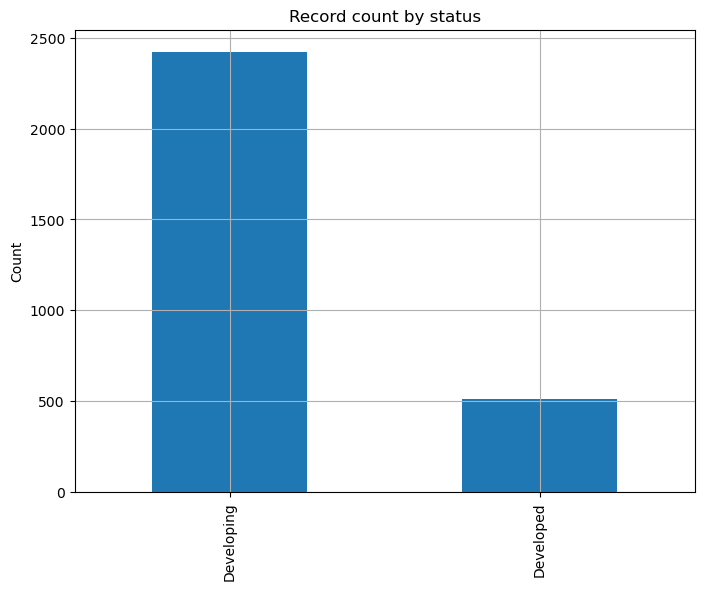

In [149]:
plt.figure(figsize=(8,6))
counts = data["status"].value_counts()
counts.plot(kind="bar");
plt.xlabel('');
plt.ylabel("Count");
plt.title("Record count by status");
plt.grid()

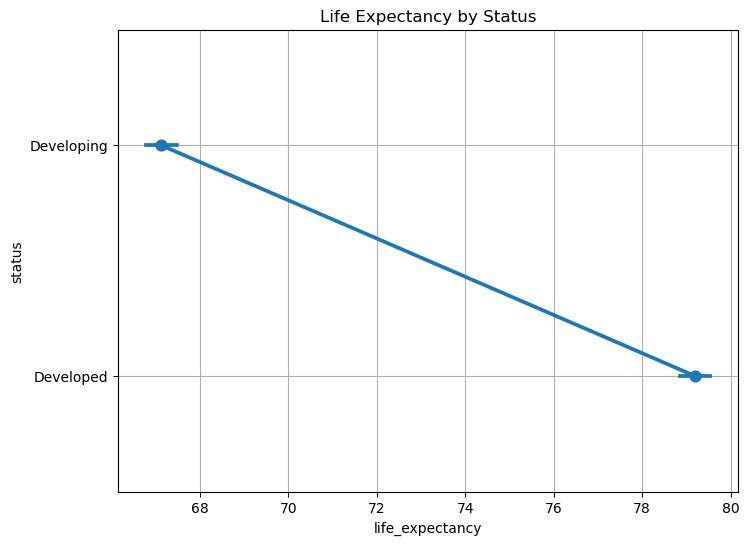

In [150]:
plt.figure(figsize=(8,6))
sns.pointplot(data, y="status", x="life_expectancy");
plt.title("Life Expectancy by Status");
plt.grid()

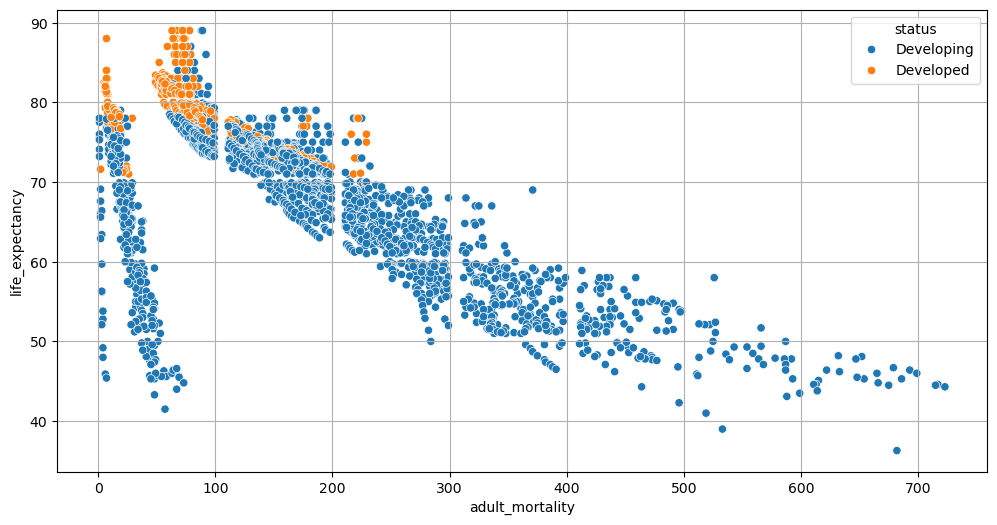

In [151]:
plt.figure(figsize=(12,6))
sns.scatterplot(data, x="adult_mortality",y="life_expectancy", hue="status")
plt.grid()

In [152]:
from scipy.stats import f_oneway
developing = data[data['status']=="Developing"]["life_expectancy"]
developed = data[data['status']=="Developed"]["life_expectancy"]
f_oneway(developed, developing, nan_policy = 'omit')

F_onewayResult(statistic=886.1555582795149, pvalue=2.4650861700059935e-170)

Visualisation and Anova test shown us, that there's a big difference between counties that are developing and those caounties that are developed - which can be a good thing to stratify the data.

## 3.2 Checking the Country Variable

Based on the plot that is shown above we can see that Countries differs from one another. The biggest issue by stratifying the data by `status` is that, the model will not be trained for each country, beacause sample data will not take countries into consideration. For experimentation purposes we will create two datasets:

* One will be stratified by status
* One will be stratified by counties (that appear more than five times in the dataset)

For each of those datasets we will perform the same calculations, however for purpose of this notebook we will focus on analysing the data that will be stratified by `status`.

In [153]:
from sklearn.model_selection import train_test_split

countries = data["country"].value_counts()[data["country"].value_counts() > 5].index
data_country_split = data[data['country'].isin(countries)]

# Splitting by Country
train_data_country, temp_data_country = train_test_split(
    data_country_split,
    train_size=0.7,
    stratify=data_country_split['country']
)

val_data_country, test_data_country = train_test_split(
    temp_data_country,
    train_size=0.5, #50% per each sample
    stratify=temp_data_country['country']
)


# Splitting by Status

train_data_status, temp_data_status = train_test_split(
    data,
    train_size=0.7,
    stratify=data['status']
)

val_data_status, test_data_status = train_test_split(
    temp_data_status,
    train_size=0.5,
    stratify=temp_data_status['status']
)

In [154]:
data['status'].value_counts() / len(data) * 100

status
Developing    82.573179
Developed     17.426821
Name: count, dtype: float64

In [155]:
train_data_status['status'].value_counts() / len(train_data_status) * 100

status
Developing    82.587549
Developed     17.412451
Name: count, dtype: float64

In [156]:
val_data_status['status'].value_counts() / len(val_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

In [157]:
test_data_status['status'].value_counts() / len(test_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

# 4. Exploratory Data Analysis

In this part:

* Check the quality of the data,

* Clean the data,

* Search for valuable correlation between the features,

* Prepare the data for modelling by building dedicated pipelines.


## 4.1 Data Cleansing

As we know from the second chapter, we have some features with missing data. In this subchapter we will try to do someting about it to increase the quality of the data.

In [158]:
missing_value_cols = train_data_status.columns[train_data_status.isnull().any()].tolist()
train_data_status[missing_value_cols].describe()

,life_expectancy,adult_mortality,alcohol,hepatitis_b,bmi,polio,total_expenditure,diphtheria,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2052.000000,2052.000000,1908.000000,1653.000000,2034.000000,2043.000000,1884.000000,2043.000000,1728.000000,1.605000e+03,2034.000000,2034.000000,1934.000000,1934.000000
mean,69.129337,165.783138,4.642285,81.090744,37.948230,82.183554,5.911072,81.981400,7577.622136,1.231061e+07,4.882793,4.905457,0.628721,11.977611
std,9.604353,125.464513,4.070180,25.039175,19.957965,23.980793,2.510138,24.130007,14630.241812,5.844667e+07,4.438666,4.499121,0.208297,3.325722
min,39.000000,1.000000,0.010000,1.000000,1.400000,3.000000,0.370000,2.000000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,63.000000,73.000000,0.917500,77.000000,19.200000,77.500000,4.250000,78.000000,462.043168,1.955530e+05,1.600000,1.600000,0.497000,10.100000
50%,71.900000,144.000000,3.750000,92.000000,42.450000,93.000000,5.710000,93.000000,1802.336437,1.354775e+06,3.300000,3.350000,0.675500,12.300000
75%,75.600000,228.000000,7.712500,96.000000,55.900000,97.000000,7.460000,97.000000,5878.097902,6.974442e+06,7.300000,7.300000,0.779000,14.200000
max,89.000000,723.000000,17.870000,99.000000,83.300000,99.000000,17.600000,99.000000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


As we know from previous analysis, countries can vary from eachother, and by that it could be a bad idea to fill the missing values by metrics like `median` or `mean`. Instead, we will use `KNNInputer` which search for n number of closest neighbors and take the mean value from them to fill a missing value.

In [159]:
from sklearn.impute import KNNImputer

inputer = KNNImputer(n_neighbors=7)
values = inputer.fit_transform(train_data_status[missing_value_cols])
train_data_status[missing_value_cols] = values
number_of_nans = train_data_status.isnull().sum().sum()
print(f"Number of empty values in dataset: {number_of_nans}")


Number of empty values in dataset: 0


For keeping the train data as clean as we can, we will perform analysis on the copy of the train dataset.

In [160]:
experimental_train_data = train_data_status.copy()
experimental_train_data = experimental_train_data.reset_index()
experimental_train_data.drop('index',axis=1, inplace=True)

## 4.2 Data Visualisation and Statistical Analysis

In this part we will try to visualise the data to get better insights into the data. We will also try to use some statistic knowledge to try to extract what's the best in those features.

### 4.2.1 Dealing with Skewed data

In this section we will perform the analysis of descriptive statistics.

In [161]:
desc = experimental_train_data.describe()
skew = experimental_train_data.select_dtypes(np.number).skew()
desc.loc["skew"] = skew
desc

,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2.056000e+03,2056.000000,2056.000000,2056.000000,2056.000000
mean,69.136048,165.660853,31.456712,4.665750,734.828637,80.566287,2484.652724,37.809776,43.668774,82.151334,5.906991,81.941634,1.733025,7242.276036,1.149282e+07,4.900681,4.923430,0.628278,11.959825
std,9.598004,125.375832,123.232280,3.991394,2021.329809,24.265315,11064.387621,19.937794,167.924339,23.934285,2.473210,24.086662,4.898939,13707.587829,5.190412e+07,4.424811,4.483663,0.207583,3.338999
min,39.000000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.400000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,63.000000,73.000000,0.000000,1.100000,3.743396,76.000000,0.000000,19.100000,0.000000,77.000000,4.247500,78.000000,0.100000,528.214420,3.658617e+05,1.600000,1.600000,0.491000,10.000000
50%,71.900000,144.000000,3.000000,3.820000,61.805928,91.000000,17.000000,42.150000,4.000000,93.000000,5.710714,93.000000,0.100000,2154.146700,2.263166e+06,3.400000,3.400000,0.675000,12.300000
75%,75.600000,228.000000,22.000000,7.632500,438.989617,97.000000,403.500000,55.900000,27.000000,97.000000,7.430000,97.000000,0.800000,6056.773185,8.263543e+06,7.300000,7.300000,0.781000,14.300000
max,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,182485.000000,83.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000
skew,-0.594188,1.150449,9.686690,0.584142,4.805946,-1.826679,8.758680,-0.181311,9.389783,-2.040452,0.633415,-2.018405,5.390799,3.485252,1.833117e+01,1.698313,1.761023,-1.068026,-0.545899


As first glance we can see, that most of our data will be needing scalling, cause many columns are in different scale. The second thing we can notice, is that we have some really skewed data (both left and right sided) which may impact the result of the modelling. Let's see how they look like, and what can we do about them.

In [162]:
skewed_cols = skew.index[np.abs(skew.values) > 1].to_list()

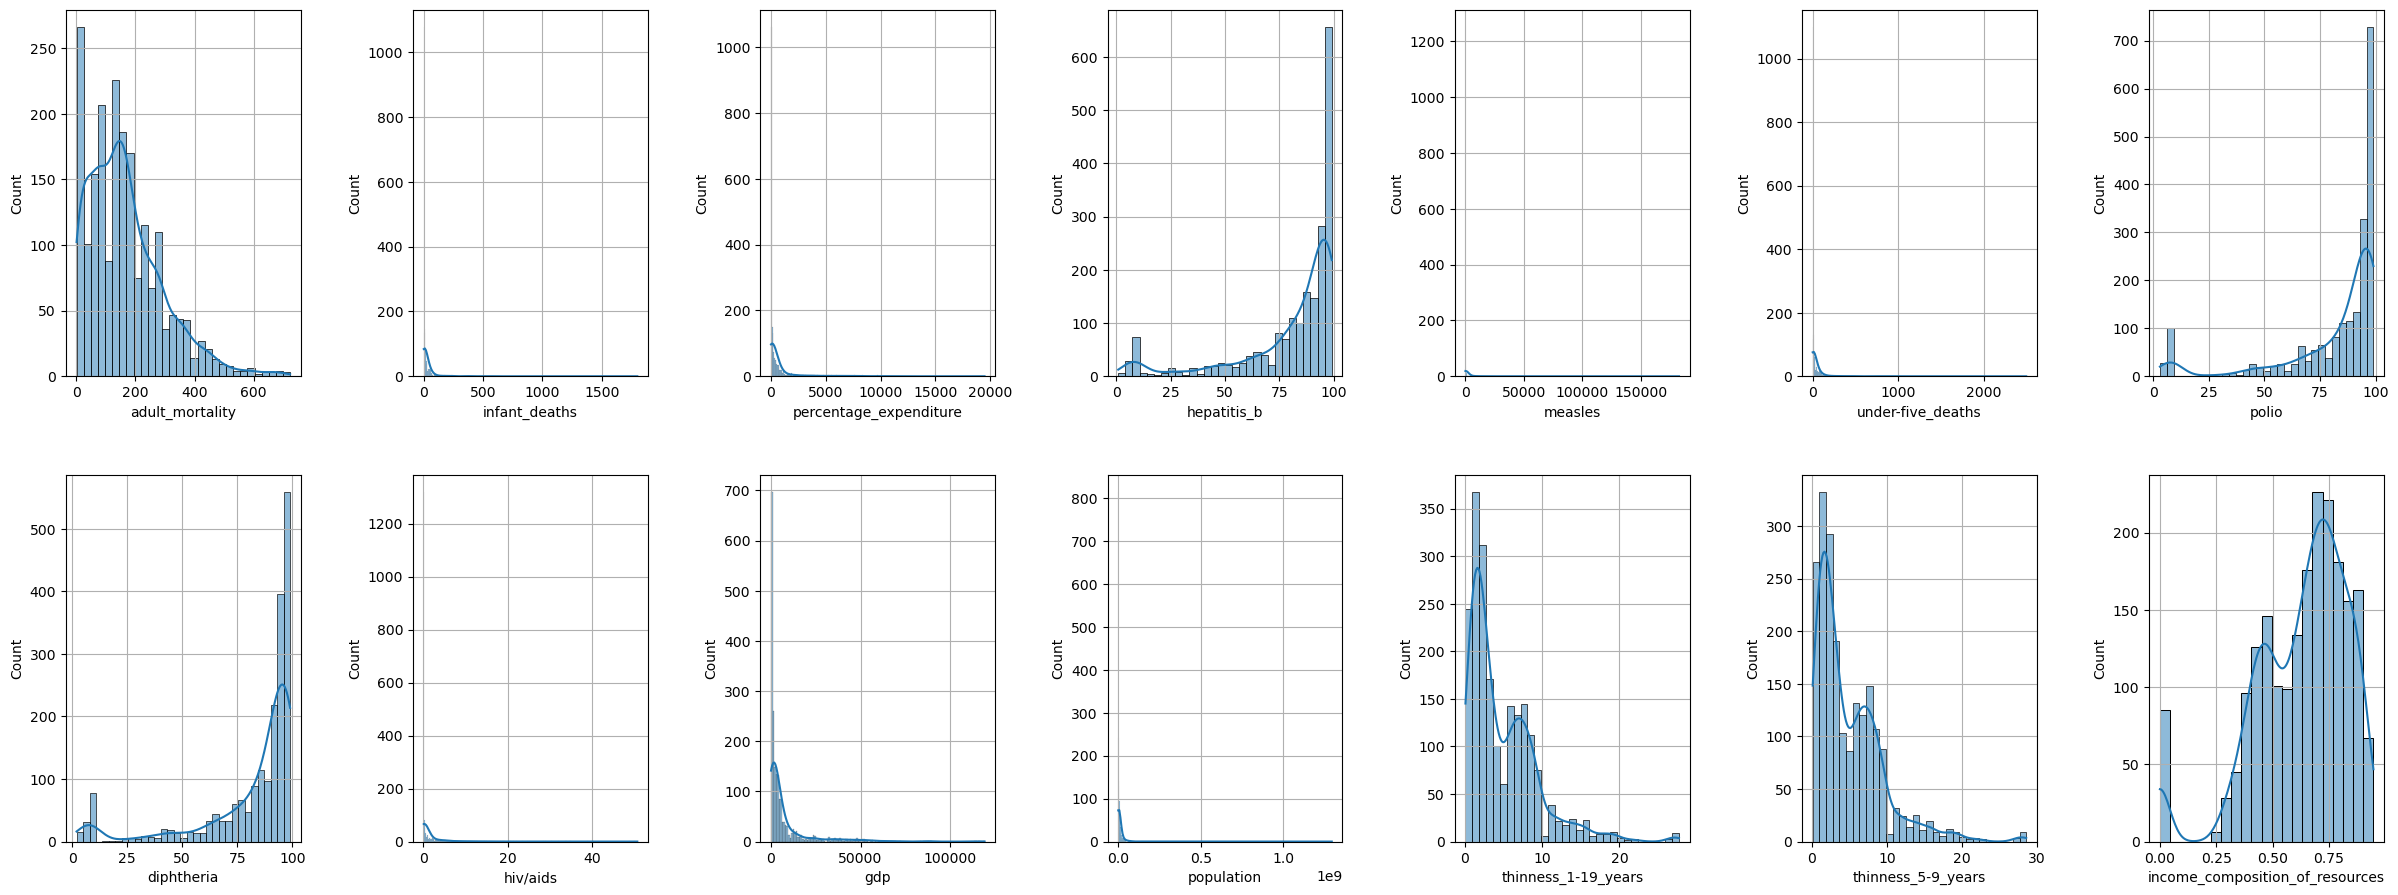

In [163]:
fig, ax = plt.subplots(2,7, figsize=(25,10))
fig.tight_layout(pad=5.)
for i,col in enumerate(skewed_cols):
    row = i // 7
    col_idx = i % 7
    sns.histplot(data=experimental_train_data, x=experimental_train_data[col], ax=ax[row,col_idx], kde=True).grid(True)

For features that are skewed to the right, we can take `log` from them to make them look more normal like distributed. For left skewed data we can use many different transformations (like Box-cox, or taking the feature to the `n` power.) to also make them more normal distributed. We also can see several features with bimodal distribution, we will perform the `RBF` (radial basis function) to calculate the probability of each sample to the modes in each feature.

C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: di

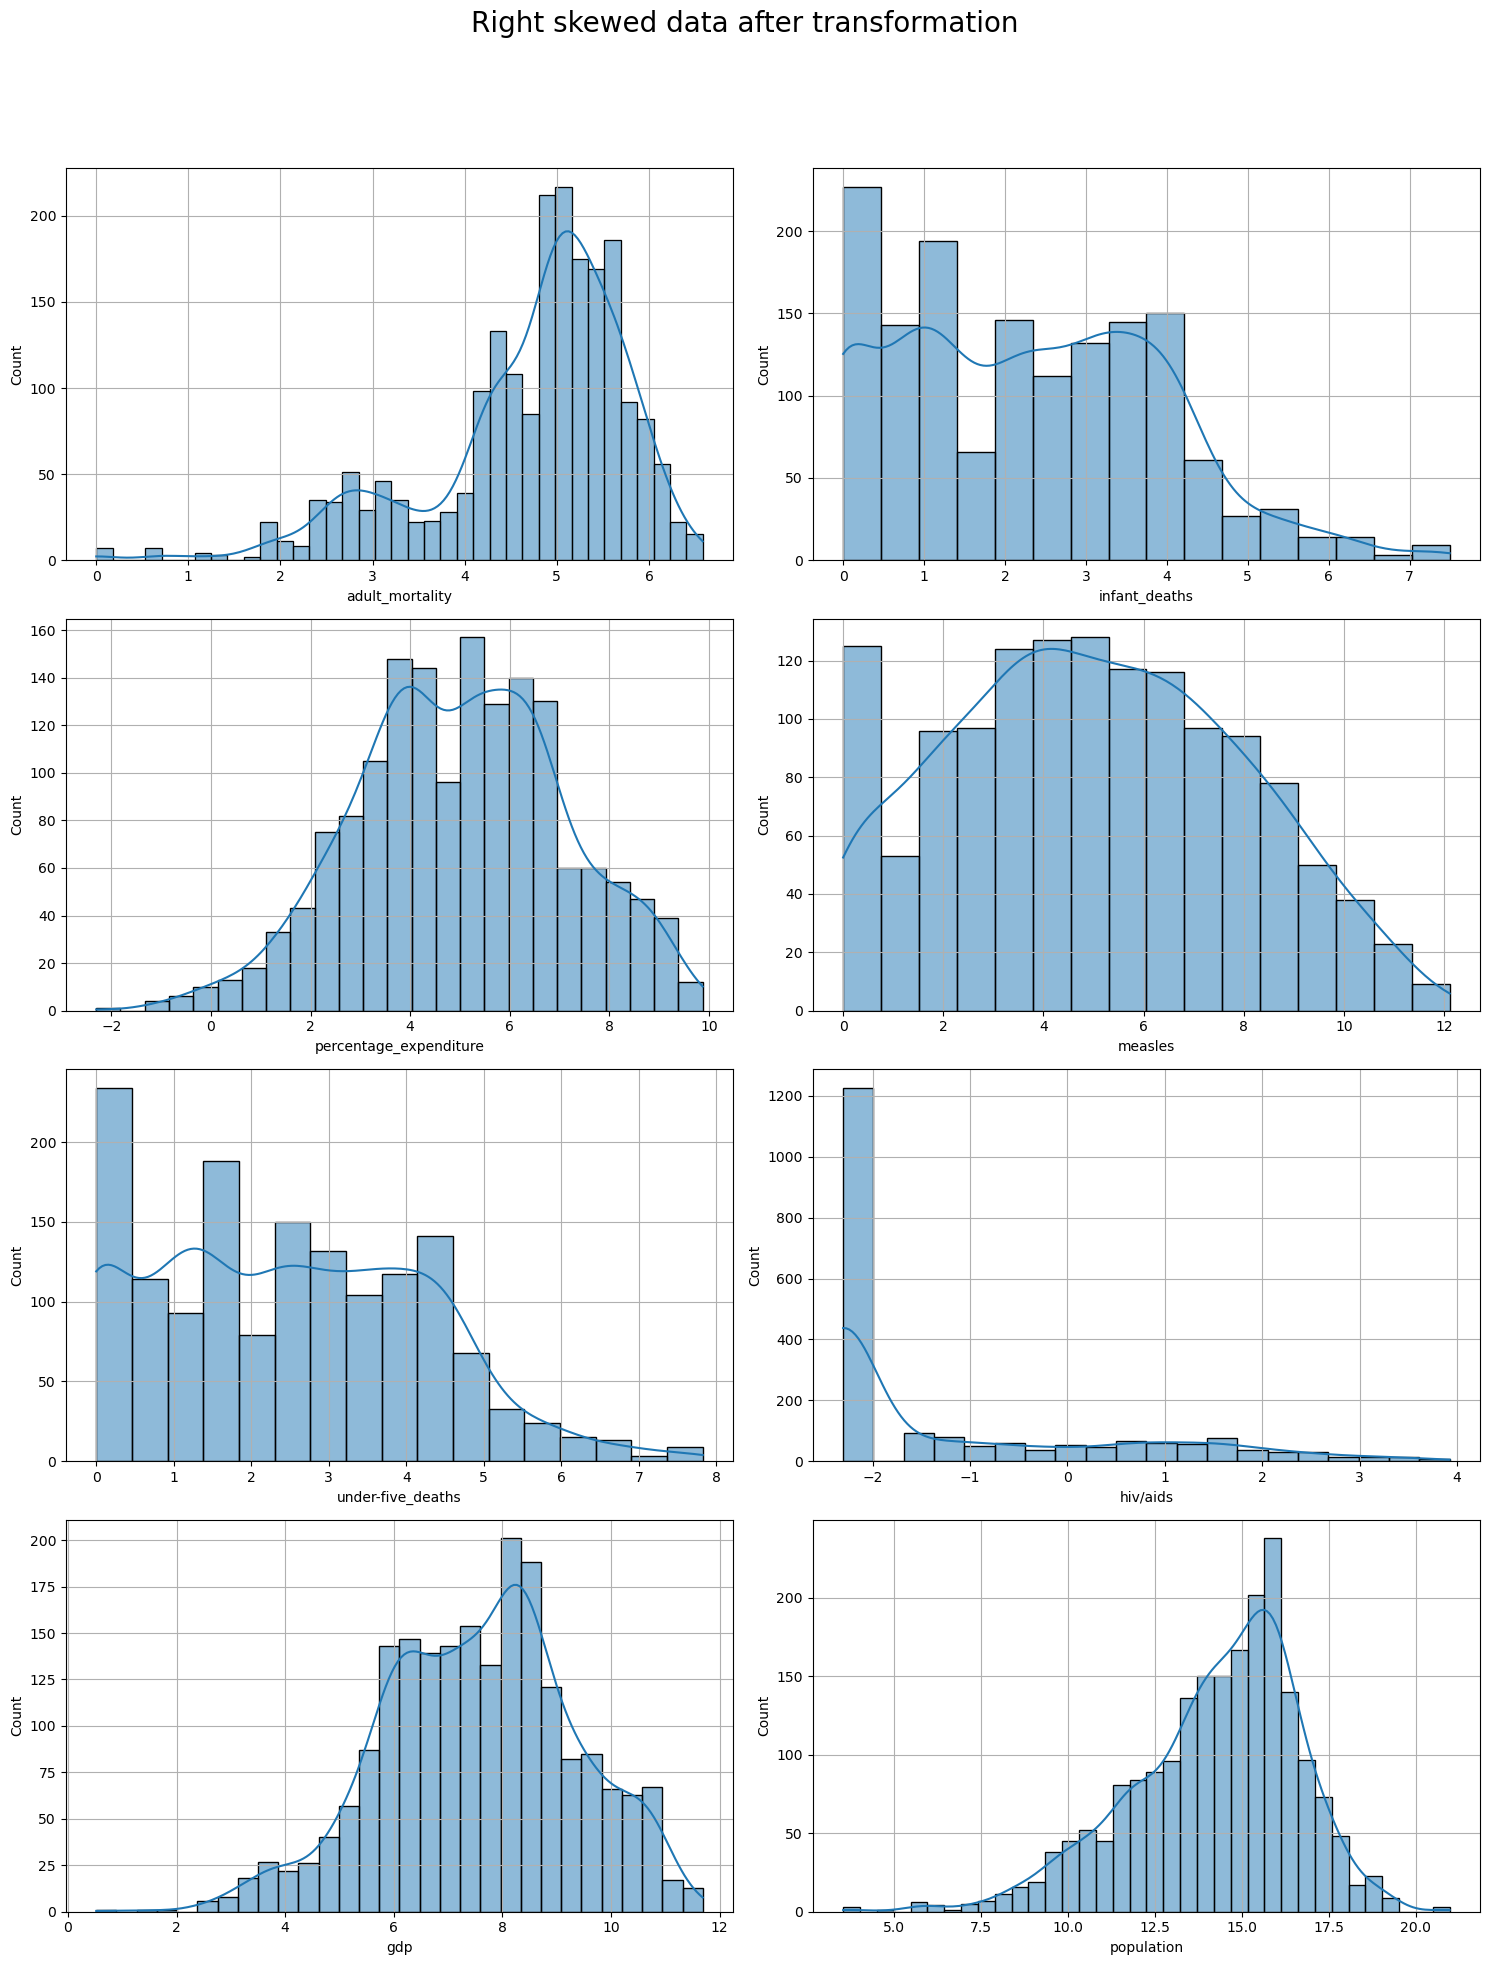

In [164]:
log_skewed_features = skew.index[skew.values > 1].to_list()[:-2] # removing the bimodal features

fig, ax = plt.subplots(4,2, figsize=(15,20))
fig.suptitle("Right skewed data after transformation", fontsize=20)
for i, col in enumerate(log_skewed_features):
    row = i // 2
    col_idx = i % 2
    #data = train_data_status[train_data_status[col]>0]
    sns.histplot(np.log(experimental_train_data[col]), kde=True, ax = ax[row, col_idx]).grid(True)
    experimental_train_data[f"log_{col}"] = np.log(experimental_train_data[col]).replace([np.inf, -np.inf], 0)
plt.tight_layout(rect=[0, 0, 1, 0.93])

Lets see the results of the transformation:

In [165]:
log_trans_features = [col for col in experimental_train_data.columns if 'log_' in col]
print("Skewness before transformation:\n")
print(experimental_train_data[log_skewed_features].skew(),"\n")

print("Skewness after transformation:\n")
print(experimental_train_data[log_trans_features].skew())

Skewness before transformation:

adult_mortality            1.150449
infant_deaths              9.686690
percentage_expenditure     4.805946
measles                    8.758680
under-five_deaths          9.389783
hiv/aids                   5.390799
gdp                        3.485252
population                18.331170
dtype: float64 

Skewness after transformation:

log_adult_mortality          -1.233203
log_infant_deaths             0.751586
log_percentage_expenditure   -0.061908
log_measles                   0.547781
log_under-five_deaths         0.673026
log_hiv/aids                  1.233337
log_gdp                      -0.211987
log_population               -0.741839
dtype: float64


As we see taking `log` from right skewed data, can significantly lower the skewness in our data and (probably) increase the correlation with target variable (we will check it a little bit later). Now - lets focus on left skewed data.

(0.0, 1.0, 0.0, 1.0)

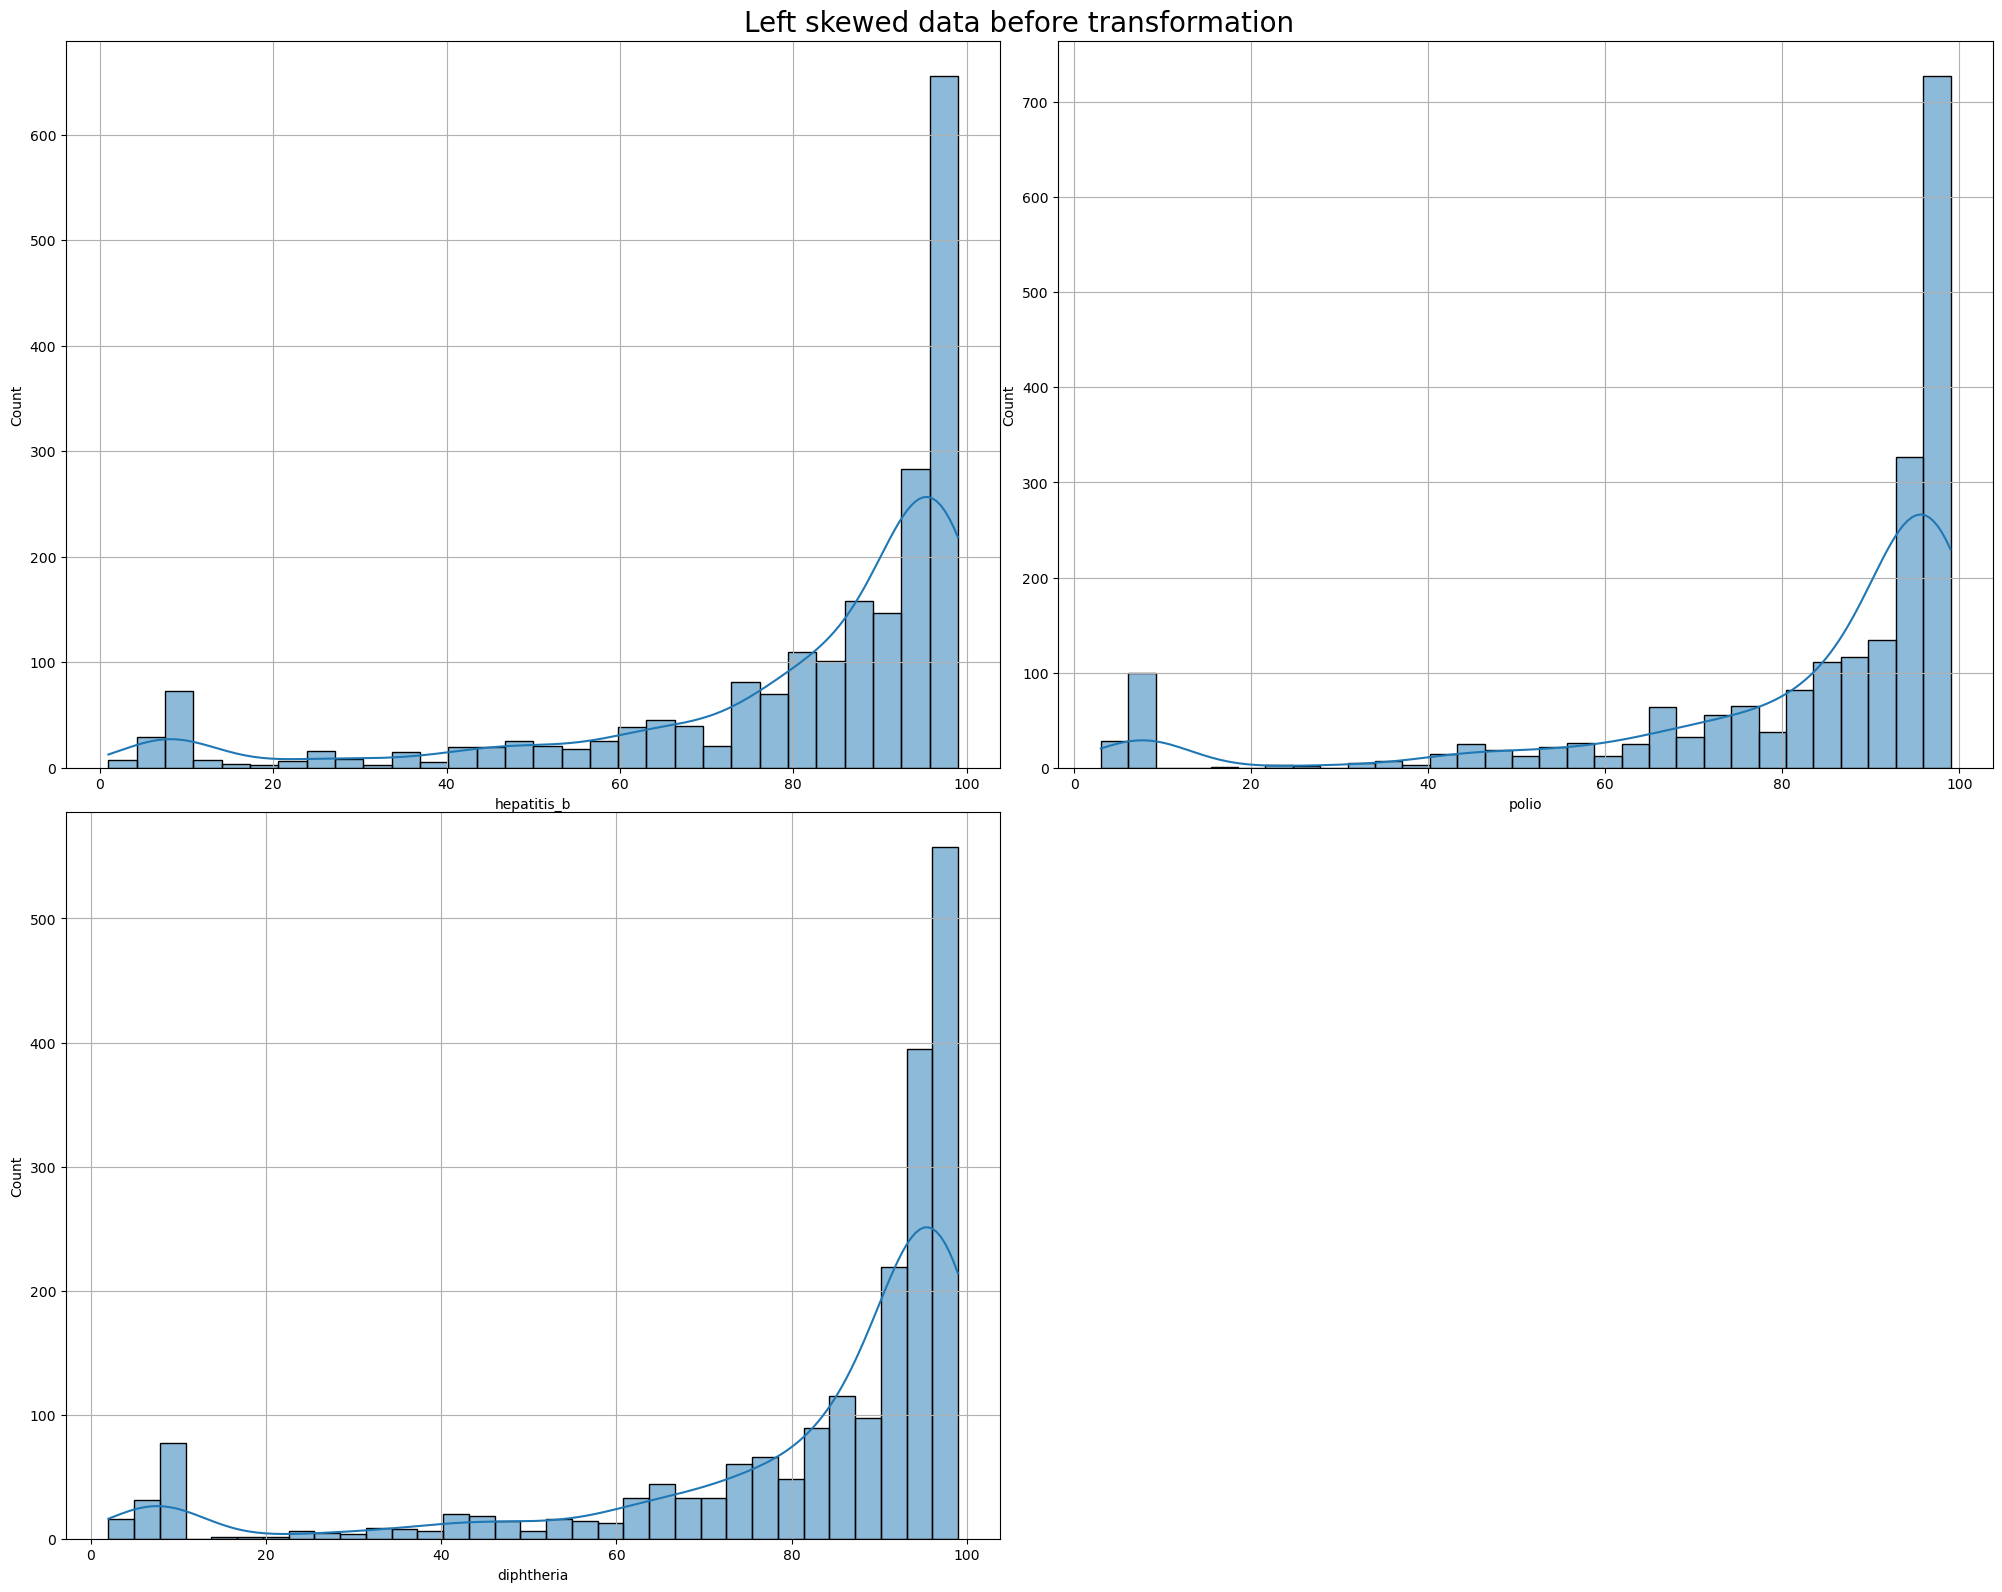

In [166]:
left_skewed_features = skew.index[skew.values < -1].to_list()[:-1] #Removing the bimodal feature

fig, ax = plt.subplots(2,2,figsize=(20,16))
fig.suptitle("Left skewed data before transformation", fontsize=20, );
fig.tight_layout()
for i, col in enumerate(left_skewed_features):
    row = i // 2
    col_idx = i % 2
    sns.histplot(experimental_train_data[col], kde=True, ax=ax[row, col_idx]).grid(True)
ax[1,1].axis('off')

(0.0, 1.0, 0.0, 1.0)

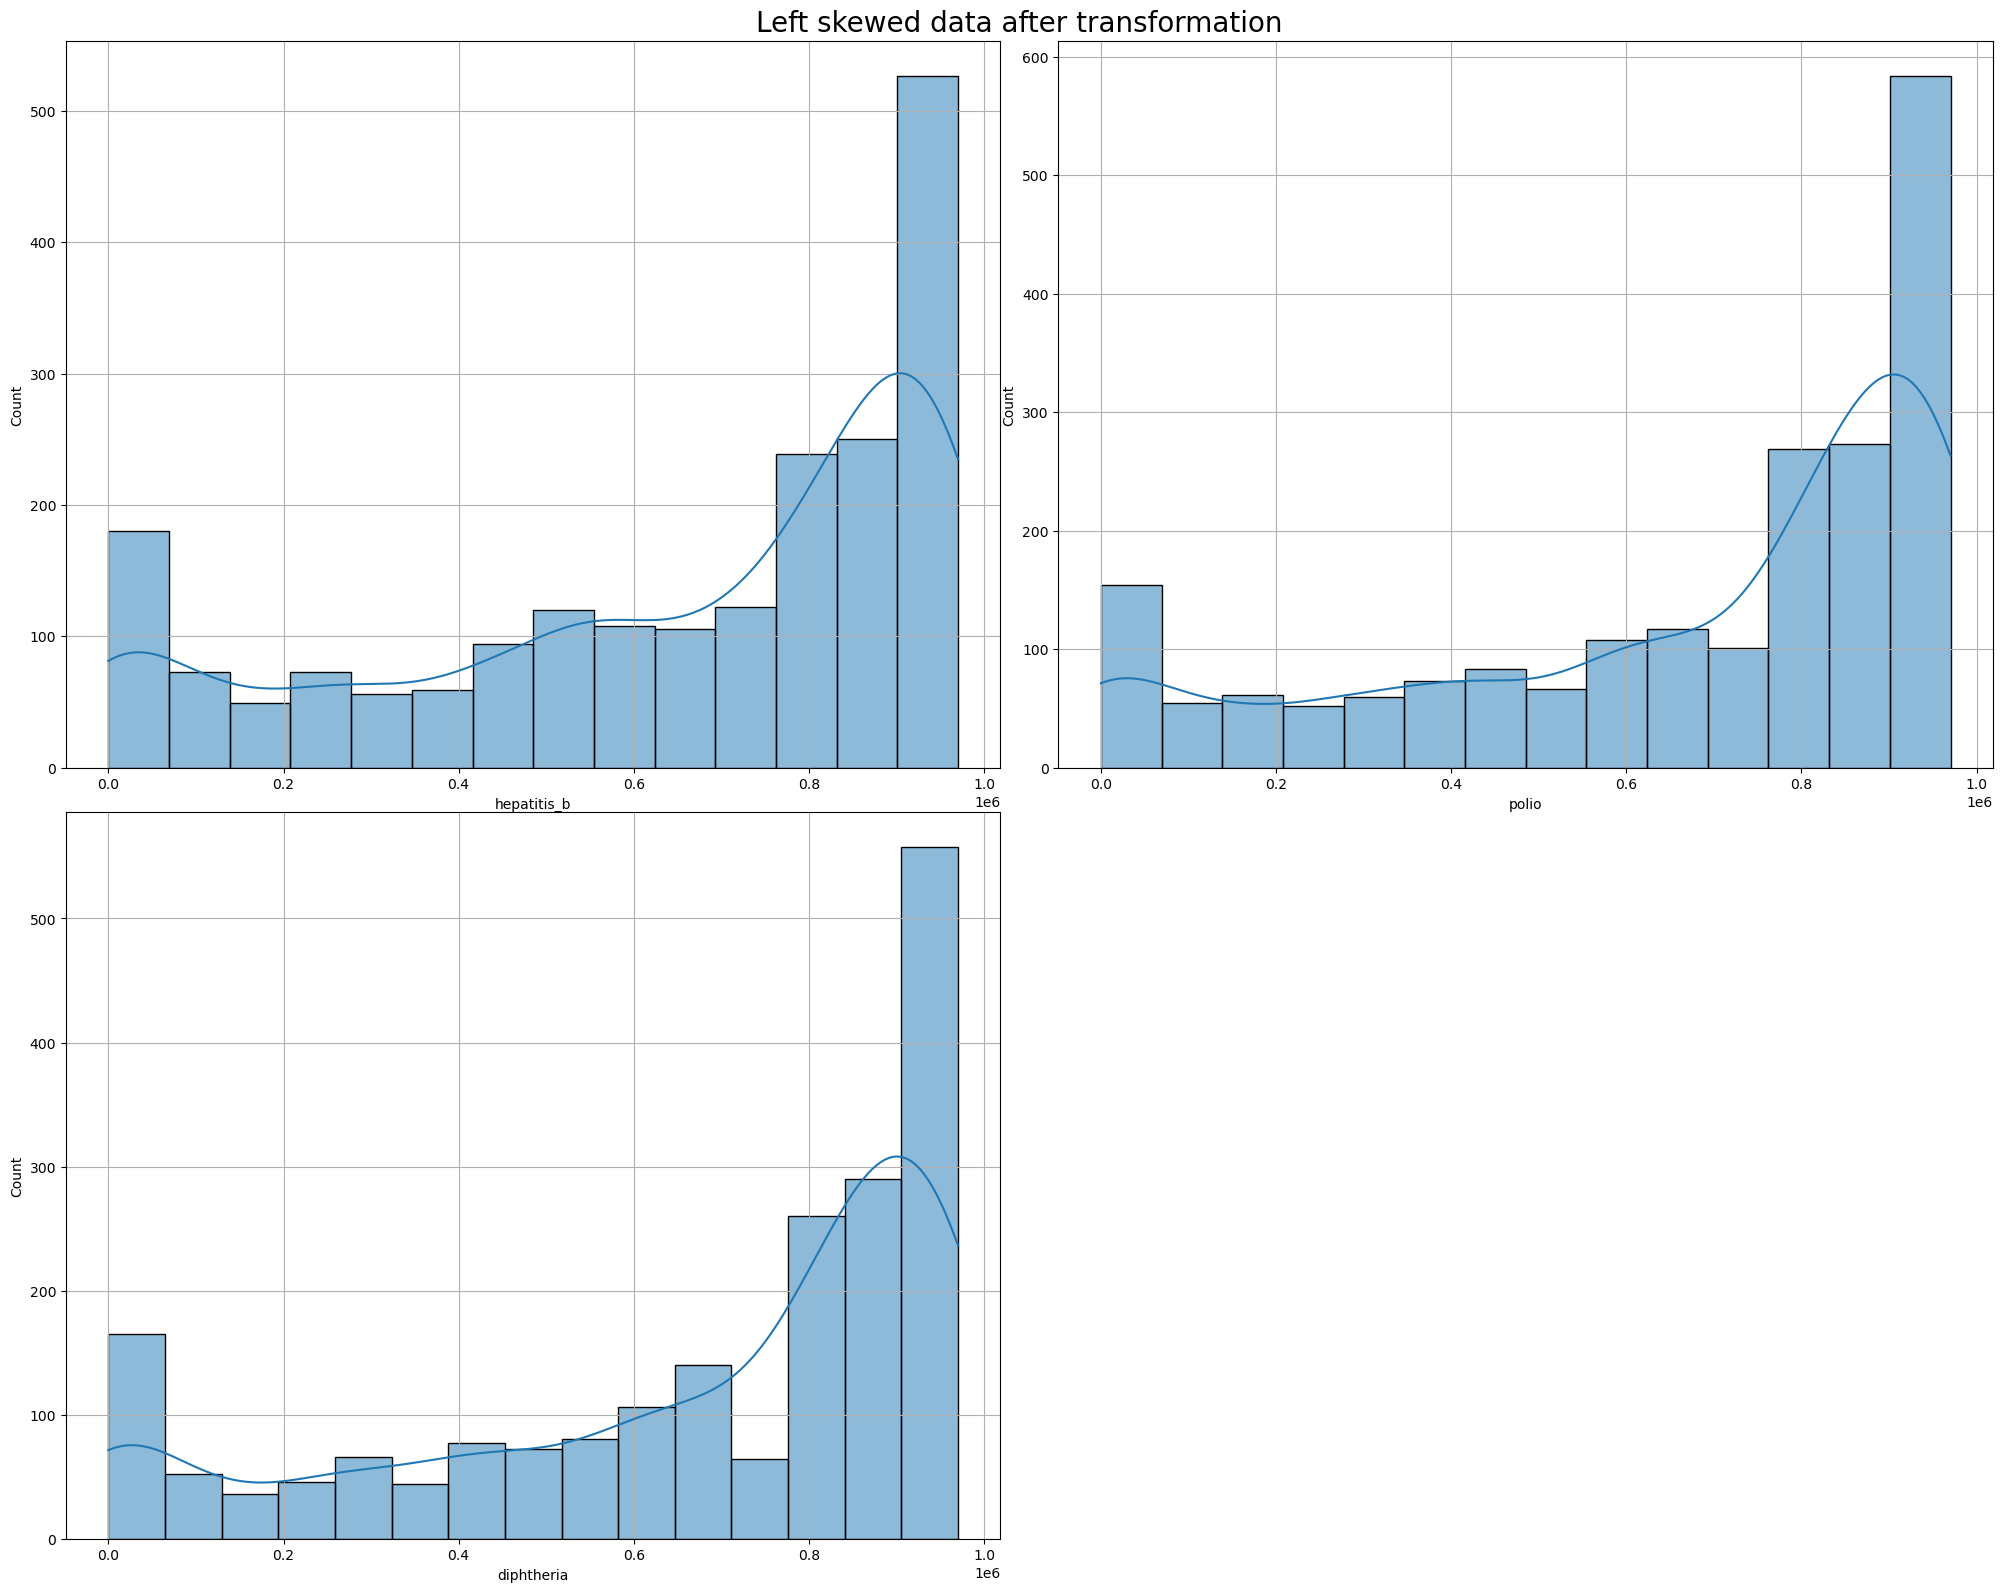

In [167]:
fig, ax = plt.subplots(2,2,figsize=(20,16))
fig.suptitle("Left skewed data after transformation", fontsize=20);
fig.tight_layout()
for i, col in enumerate(left_skewed_features):
    row = i // 2
    col_idx = i % 2
    sns.histplot(experimental_train_data[col]**3, ax=ax[row, col_idx], kde=True).grid(True) #Taking the feature to the third power.
    experimental_train_data[f"pow3_{col}"] = experimental_train_data[col]**3
ax[1,1].axis('off')

In [168]:
power_cols = [col for col in experimental_train_data.columns if 'pow3' in col]
print("Skewness before transformation: \n")
print(experimental_train_data[left_skewed_features].skew(), "\n")
print("Skewness after transformation: \n")
print(experimental_train_data[power_cols].skew())

Skewness before transformation: 

hepatitis_b   -1.826679
polio         -2.040452
diphtheria    -2.018405
dtype: float64 

Skewness after transformation: 

pow3_hepatitis_b   -0.790899
pow3_polio         -0.940451
pow3_diphtheria    -0.953557
dtype: float64


Taking the features to the power of 3 seems like a good idea to reduce the skewness in our data, however it's only working with left skewed data. Now let's focus on the binominal features. We will build a custom transformer that will measure the probability of belonging to a particular cluster defined by `KMeans` algorithm.

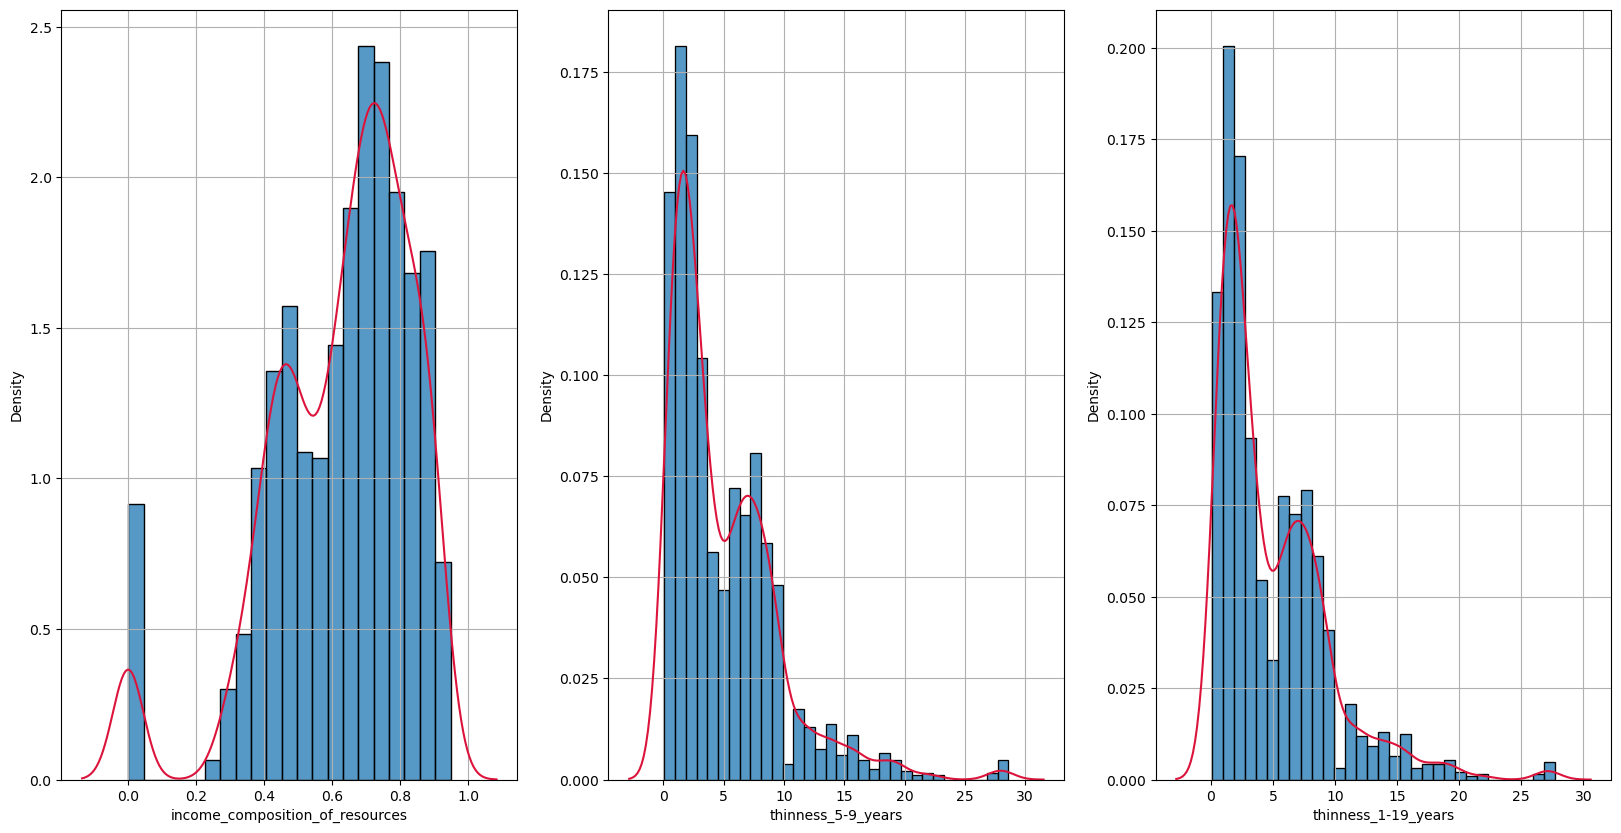

In [169]:
binom_features = ['income_composition_of_resources','thinness_5-9_years','thinness_1-19_years']
fig, ax = plt.subplots(1,3, figsize=(20,10))
for i, col in enumerate(binom_features):
    sns.histplot(experimental_train_data[col], ax=ax[i], kde=False, stat='density')
    sns.kdeplot(experimental_train_data[col], ax=ax[i], color='crimson')
    ax[i].grid(True)

In [170]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=3, gamma = 0.1, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"proba_{i}_cluster" for i in range (self.n_clusters)]



In [171]:
CS = ClusterSimilarity(n_clusters=3)
preds = CS.fit_transform(experimental_train_data[['thinness_5-9_years','thinness_1-19_years']]).round(3)
CS_data = pd.DataFrame(
    preds,
    columns=CS.get_feature_names_out()
)
CS_data


C:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,proba_0_cluster,proba_1_cluster,proba_2_cluster
0,0.003,1.000,0.0
1,0.818,0.000,0.0
2,0.865,0.014,0.0
3,0.070,0.512,0.0
4,0.982,0.005,0.0
...,...,...,...
2051,0.992,0.002,0.0
2052,0.542,0.000,0.0
2053,0.005,0.971,0.0
2054,0.113,0.385,0.0


In case of `income_composition_of_resources`, we will leave the feature as it is. Our cluster method will probably not work, because there's not much fluctuaion in the data, so cluster centers will be close to eachother, and by that our method with calculating probability will assign high probability to each cluster:

In [172]:
experimental_train_data = experimental_train_data.join(CS_data)
experimental_train_data.head(5)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,log_under-five_deaths,log_hiv/aids,log_gdp,log_population,pow3_hepatitis_b,pow3_polio,pow3_diphtheria,proba_0_cluster,proba_1_cluster,proba_2_cluster
0,Zambia,2001,Developing,44.6,611.0,43,2.61,46.830275,79.714286,16997,...,4.248495,2.923162,5.935618,14.416611,506533.854227,636056.0,614125.0,0.003,1.000,0.0
1,Cyprus,2014,Developed,83.0,53.0,0,0.01,207.304194,96.000000,10,...,0.000000,-2.302585,7.913844,11.654764,884736.000000,970299.0,970299.0,0.818,0.000,0.0
2,Bosnia and Herzegovina,2007,Developing,75.4,16.0,0,5.16,8.240356,94.000000,166,...,0.000000,-2.302585,6.036180,8.235891,830584.000000,857375.0,857375.0,0.865,0.014,0.0
3,Djibouti,2010,Developing,61.3,273.0,1,0.44,187.496010,88.000000,7,...,0.693147,1.131402,7.189920,13.654339,681472.000000,681472.0,681472.0,0.070,0.512,0.0
4,Paraguay,2004,Developing,71.9,165.0,3,6.20,20.600830,9.000000,0,...,1.386294,-1.609438,5.000773,10.957347,729.000000,778688.0,778688.0,0.982,0.005,0.0


### 4.2.2 Plotting the Data

In this part, we will try to visulise the data, in order to get better understanding about the relations of the data, and try to understand what features have negative or positive impact on life expectancy. One thing that we know, that `status` column highly impact the value of the life_expectancy. But first let's check if our created features increased the values of correlation.

In [173]:
def find_correlated_features(threshold: int, columns = None) -> pd.DataFrame:
    """
    Function that checks highly correlated features
    :param threshold: threshold of correlation. Only columns with higher or equal correlation with threshold will be displayed.
    :param columns: columns for which we want to check the correlation. (Optional argument)
    :return: DataFrame with correlated pairs
    """
    correlated_pairs = []
    if columns is not None:
        data = experimental_train_data[columns]
    else:  
        data = experimental_train_data.select_dtypes(np.number)
    for i in range(len(data.columns)):
        for j in range (i+1, len(data.columns)):
            col1 = data.columns[i]
            col2 = data.columns[j]
            corr_value = data[[col1, col2]].corr().iloc[1].values[0]
            if abs(corr_value) >= threshold:
                correlated_pairs.append((col1, col2, corr_value.round(3)))
    return pd.DataFrame(correlated_pairs, columns=["Feature_1","Feature_2","Corr"]).pivot_table(
        values="Corr",
        index="Feature_1",
        columns="Feature_2"
    )
    

<Axes: xlabel='Feature_2', ylabel='Feature_1'>

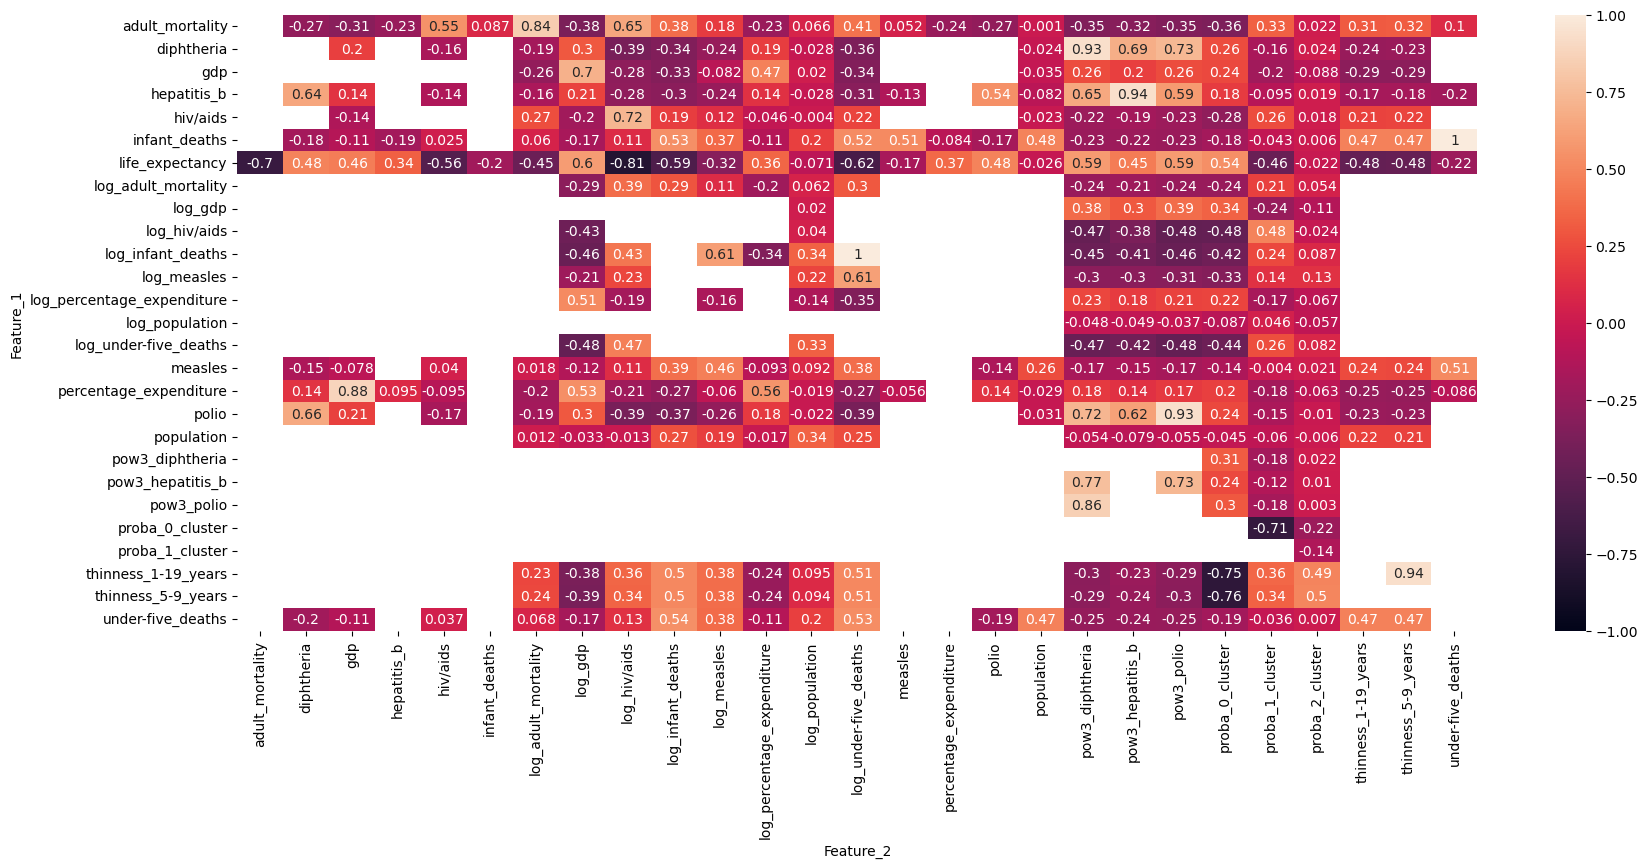

In [174]:
keywords = ['pow3','life','log_','adult','infant','percentage','measles','under-','hiv/','popul','hepati','poli','dipht','thin','proba','gdp']
cols = [col for col in experimental_train_data.columns if any(keyword in col for keyword in keywords)]
plt.figure(figsize=(20,8))
sns.heatmap(
    find_correlated_features(0, columns=cols),
    vmin=-1,
    vmax=1,
    annot=True
)

Based on that plot we can say:
* In terms of `log` transformation just `log_adult_mortality` did not increase the correlation between feature and life_expectancy.
* In terms of `cubic` transformation all of our features have increased correlation between life_expectancy and particular feature.
* In terms of `KMeans` transformation two clusters should be enough. However, features connected with thinnes are highly correlated with each other, so we will drop one of this feature
* `GDP` and `Percentage_expenditure` are also highly correlated with eachother, so one of those features will have to be dropped.

Now lets dive into visualisation. First let's check columns that are connected with immunization and sicknesses.

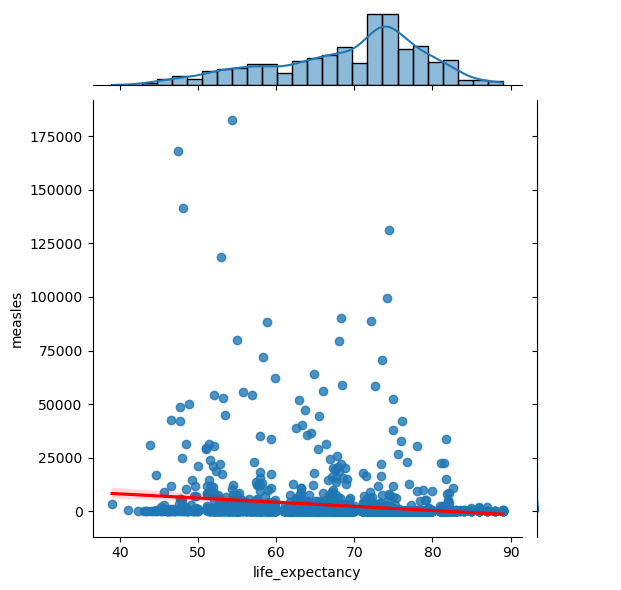

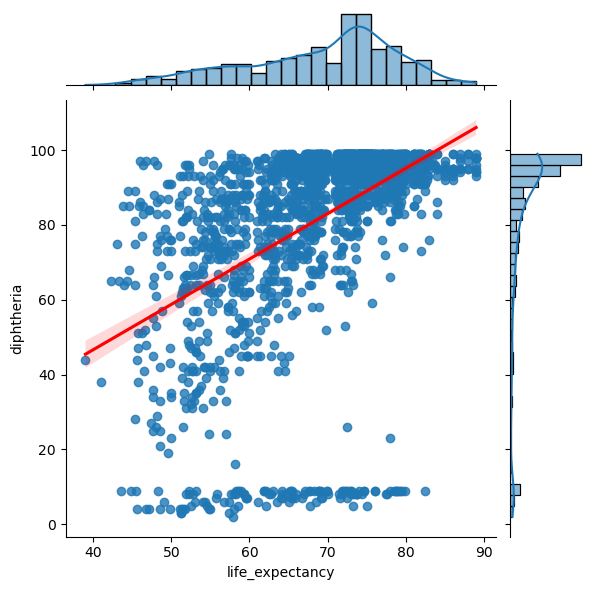

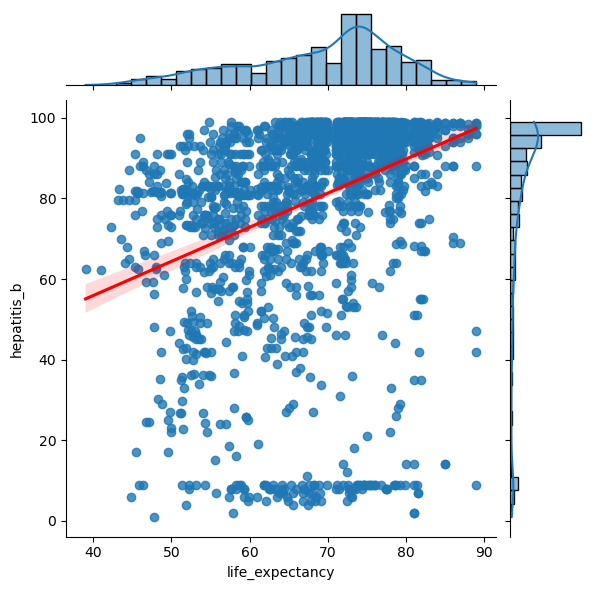

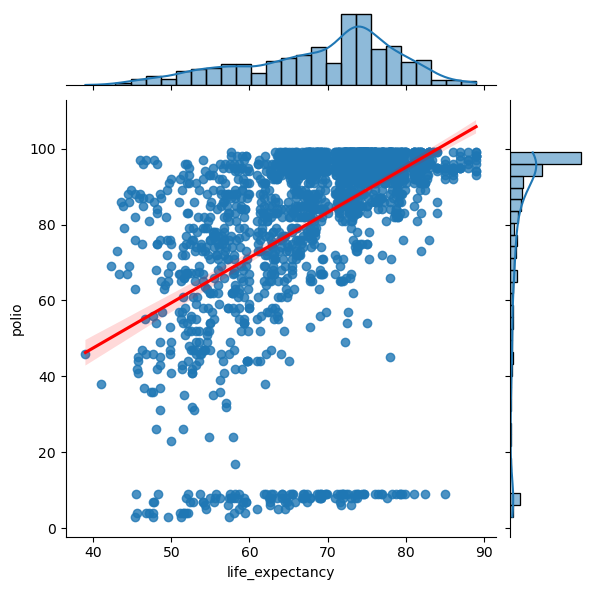

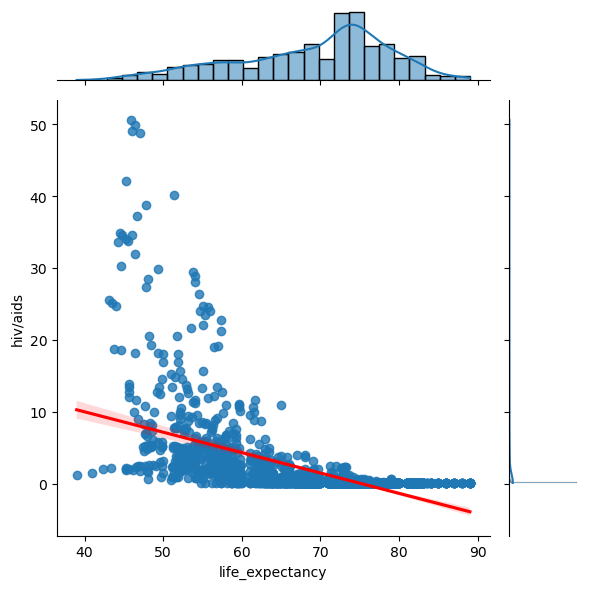

In [175]:
sickness_features = ['measles','diphtheria','hepatitis_b','polio', 'hiv/aids']
for i,col in enumerate(sickness_features):
    sns.jointplot(
        data=experimental_train_data,
        x='life_expectancy',
        y=col,
        kind="reg",
        line_kws={'color':'red'}
    )
plt.tight_layout()


Based on that we can say, that if a great part of country population is immunized (by vaccination or other forms) to a particular disease, life expectancy of that country can increase dramatically. Now let's check information about general condition of the countries, and how they impact the life expectancy.

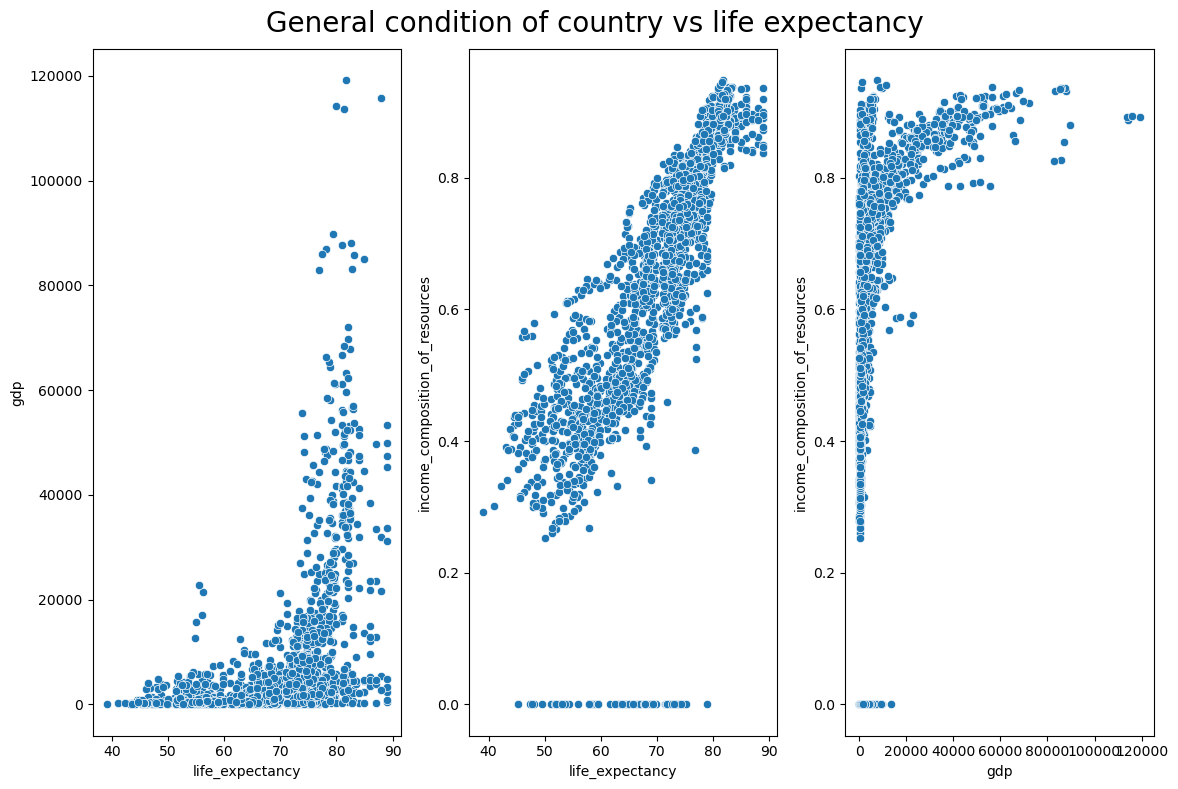

In [176]:
condition_features = ['gdp','income_composition_of_resources']
fig, ax = plt.subplots(1,3,figsize=(12,8))
for i in range(len(condition_features)+1):
    if i == 2:
        sns.scatterplot(
            data=experimental_train_data,
            x=condition_features[0],
            y=condition_features[1],
            ax=ax[i]
        )
    else:
        sns.scatterplot(
            data=experimental_train_data,
            x='life_expectancy',
            y=condition_features[i],
            ax=ax[i]
        )
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("General condition of country vs life expectancy", fontsize=20);


As our logic says, the richer / better developed country is, the longer we can expect people to live. 

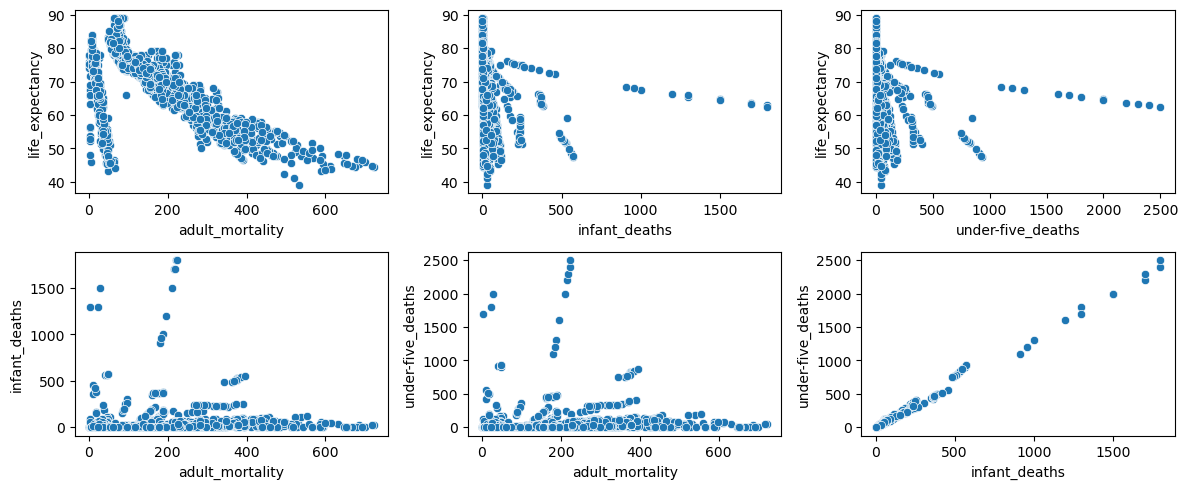

In [177]:
death_features = ['adult_mortality','infant_deaths','under-five_deaths']
fig, ax = plt.subplots(2,3,figsize=(12,5))
for i in range(len(death_features)+3):
    
    if i == 3:
        sns.scatterplot(
            data=experimental_train_data,
            x=death_features[0],
            y=death_features[1],
            ax=ax[1,0]
        )
    elif i == 4:
        sns.scatterplot(
            data=experimental_train_data,
            x=death_features[0],
            y=death_features[2],
            ax=ax[1,1]
        )
    elif i == 5:
        sns.scatterplot(
            data=experimental_train_data,
            x=death_features[1],
            y=death_features[2],
            ax=ax[1,2]
        )
    else:
        sns.scatterplot(
            data=experimental_train_data,
            x=death_features[i],
            y='life_expectancy',
            ax=ax[0,i]
        )
plt.tight_layout()
   

As we see, there's some correlation between our data. For example:
* `infant_deaths` and `under-five_deaths` seems to be almost linear, this means, that they have almost the same values. So one of this feature can be dropped.
* `adult mortality` and `life expectancy` appear to be strongly negatively correlated: as the values of adult mortality increase, life expectancy tends to decrease.

The last features to visualise are: `alcohol`, `year`, `schooling` and `bmi`.

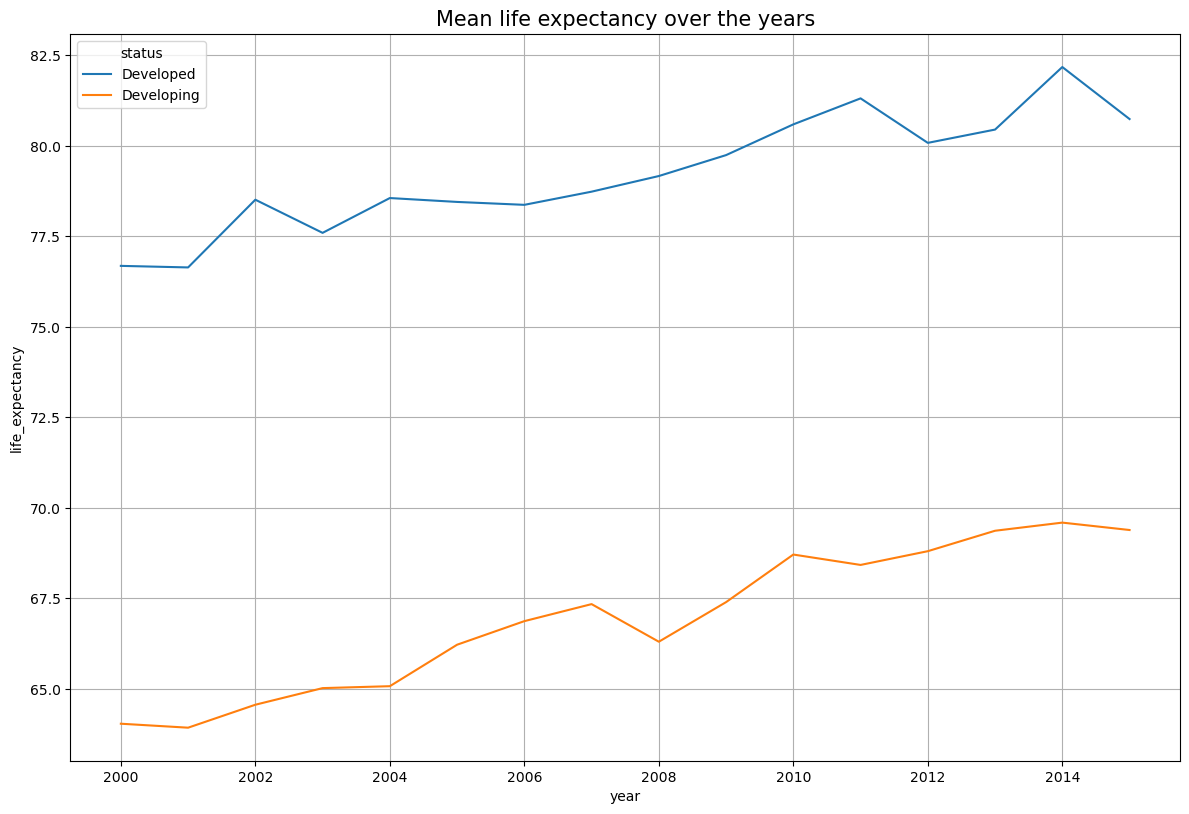

In [178]:
year_data = experimental_train_data.groupby(
    by=['status','year']
).agg(
    {'life_expectancy':'mean'}
)

plt.figure(figsize=(12,8))
sns.lineplot(
    data=year_data,
    y='life_expectancy',
    x='year',
    hue='status'
)
plt.tight_layout()
plt.title("Mean life expectancy over the years", fontsize=15);
plt.grid()

As we can see, over the years, the mean life expectancy has been increasing for both developed and developing countries. On average, life expectancy has risen by about 5 years over a span of 15 years. Now lets check the alcohol variable.

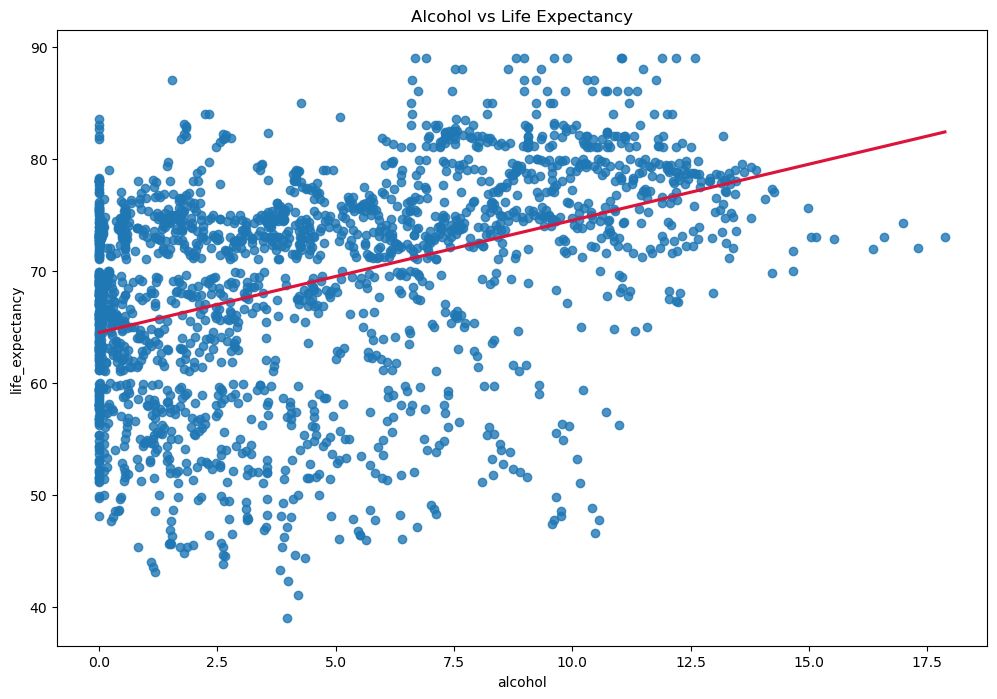

In [179]:
plt.figure(figsize=(12,8))
sns.regplot(
    data=experimental_train_data,
    x='alcohol',
    y='life_expectancy',
    line_kws={'color':'crimson'},
    ci=None
);
plt.title("Alcohol vs Life Expectancy");

And here's something interesting. Based on this plot the more particular drinks alcohol, we expect people to live longer. This statement seems not to be true, since alcohol is not good for our health. There's probably another varable that influences this behaviour. Let's look at the statistics groupped by status column.

In [180]:
experimental_train_data.groupby(
    by='status'
).agg(
    {'alcohol':['mean','median']}
).reset_index()

status   alcohol        
                   mean  median
0   Developed  9.764374  10.295
1  Developing  3.590776   2.780

Developed countries seems to drink a lot more alcohol than developing countries, but it's not a factor that increases your life expectancy - it's just a result of living in a developed country, where you can buy more easily a lot of alcohol. Lets check the correlation for both those groups.

In [181]:
developed = experimental_train_data[experimental_train_data['status']=='Developed']
developing = experimental_train_data[experimental_train_data['status']=='Developing']

developed_corr = developed[['life_expectancy','alcohol']].corr()['alcohol'].values[0].round(3)
developing_corr = developing[['life_expectancy','alcohol']].corr()['alcohol'].values[0].round(3)

print(f"Correlation between alcohol and life expectancy for developed countries: {developed_corr}")
print(f"Correlation between alcohol and life expectancy for developing countries: {developing_corr}")



Correlation between alcohol and life expectancy for developed countries: -0.29
Correlation between alcohol and life expectancy for developing countries: 0.224


We can see that, in fact the more highly developed countries drink, the lower is the life expectancy. However, in developing countries it seems that drinking alcohol can extend your life (joking)!

Let's build some basic OLS model to further analyse this variable:

In [182]:
import statsmodels.formula.api as smf
experimental_train_data['status_encoded'] = experimental_train_data['status'].apply(lambda x: 1 if x == 'Developed' else 0)
model = smf.ols('life_expectancy ~ alcohol + status_encoded * alcohol', data=experimental_train_data).fit()

In [183]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     262.8
Date:                Wed, 04 Dec 2024   Prob (F-statistic):          2.62e-144
Time:                        15:01:48   Log-Likelihood:                -7232.4
No. Observations:                2056   AIC:                         1.447e+04
Df Residuals:                    2052   BIC:                         1.450e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 64

In terms of alcohol, developed countries that drink much alcohol seems to have lower life expectancy. (Real Inpact =  $0.573 - 0.961 = -0.387$). Based od that, we will keep this variable for now. Now we're left with `schooling` and `bmi` variables.

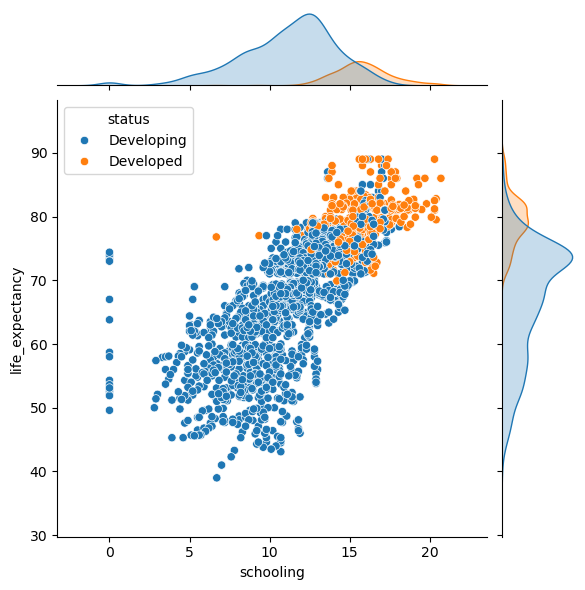

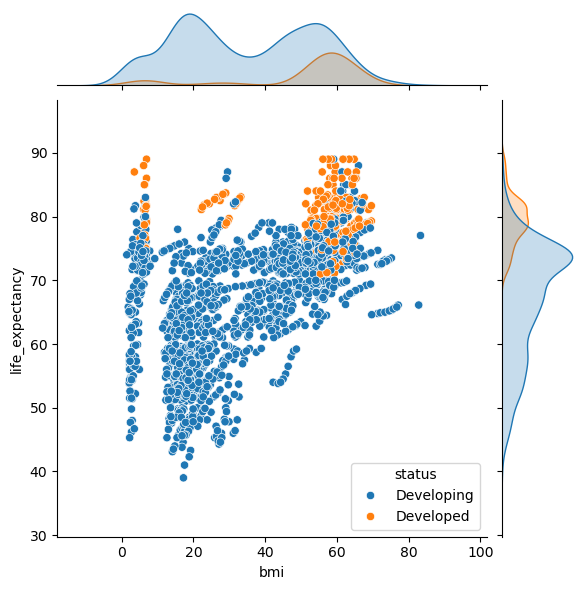

In [184]:
sch_bmi = ['schooling','bmi']
for i, col in enumerate(sch_bmi):
    sns.jointplot(
        data=experimental_train_data,
        x=col,
        y="life_expectancy",
        hue="status"
    )

Schooling seems to have significat influence on life expectancy. Better access to education seems to rise the level of life expectancy. Higher BMI seems to correlate with higher life expectancy but theres probably the same situation as in alcohol variable. Lets see how they perform on a simple OLS model.

In [185]:
model = smf.ols('life_expectancy ~ schooling + status_encoded * schooling + bmi + status_encoded*bmi', data=experimental_train_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     746.0
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        15:01:48   Log-Likelihood:                -6501.0
No. Observations:                2056   AIC:                         1.301e+04
Df Residuals:                    2050   BIC:                         1.305e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

The Real impact on Developed countries for BMI is: $0.122 - 0.146 = -0.024$, and for Schooling: $1.661 - 0.6582 = 1.002$. The last step is to check correlation for all of our variables.

<Axes: xlabel='Feature_2', ylabel='Feature_1'>

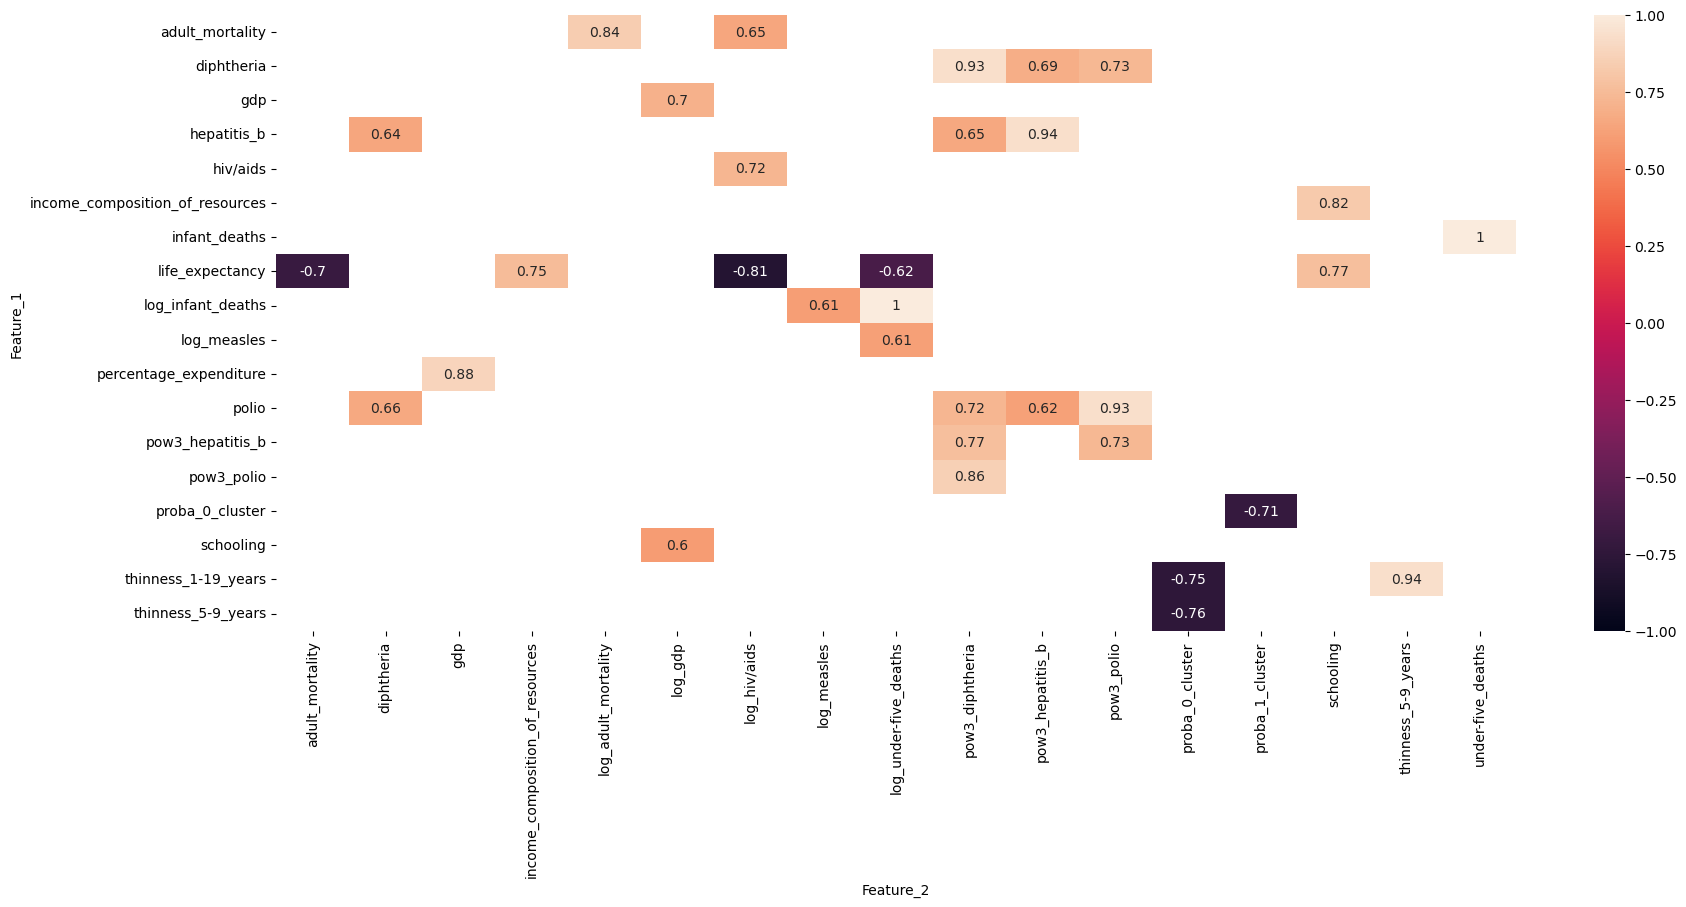

In [186]:
plt.figure(figsize=(20,8))
sns.heatmap(
    find_correlated_features(0.6),
    vmin=-1,
    vmax=1,
    annot=True
)

# 5. Building the Pipelines



In this part, we will try to build a pipeline that will prepare our data for modeling. To summarise, we will:

* Delete: `percentage_expenditure`, `under-five-deaths`, `thinness_5-9_years`, `population`,
* Perform `Log` Transformation on: `hiv/aids`, `gdp`, `measles`,
* Perform `Cubic` Transformation on: `diphtheria`, `hepatitis_b`, `polio`,
* Perform `KMeans` and `RBF` Tranformation on : `thinness_1-19_years`,
* OneHot encode categorical variables,
* Standarize necessary columns,
* Impute missing values using `KMeans` algorithm.

In [187]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

## 5.1 Logarithimic Transformer

In this part we will build a transformer that will take the `log` out of our data.

In [189]:
LOG_FEATURES = ["hiv/aids", "gdp", "measles", "under-five_deaths"]

def replace_zeros_with_min(X):
    """
    Function that replaces 0 with very small values in order to gain the possibility to log them.
    """
    return np.where(X==0, 1e-9, X)

replacing_zeros_transformer = FunctionTransformer(replace_zeros_with_min, validate=False, feature_names_out="one-to-one")
log_operation_transformer = FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one")


log_pipeline = make_pipeline(
    KNNImputer(n_neighbors=7),
    replace_zeros_transformer,
    log_operation_transformer,
    StandardScaler()
)



## 5.2 Cubic Transformer

In [190]:
CUBIC_FEATURES = ['diphtheria', 'hepatitis_b', 'polio']

def cube(X):
    return np.power(X,3)


cubic_transformer = FunctionTransformer(cube, inverse_func=np.cbrt, feature_names_out='one-to-one')

cubic_pipeline = make_pipeline(
    KNNImputer(n_neighbors=7),
    cubic_transformer,
    StandardScaler()
)

## 5.3 Cluster Pipeline

In [191]:
CLUSTER_FEATURES = ['thinness_1-19_years']
cluster_siml = ClusterSimilarity(n_clusters=3)

## 5.4 Categorical Features Pipeline

In [198]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False)
)

In [199]:
test = ColumnTransformer([
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
])

In [202]:
pd.DataFrame(test.fit_transform(experimental_train_data), columns=test.get_feature_names_out())

,cat__country_Afghanistan,cat__country_Albania,cat__country_Algeria,cat__country_Angola,cat__country_Antigua and Barbuda,cat__country_Argentina,cat__country_Armenia,cat__country_Australia,cat__country_Austria,cat__country_Azerbaijan,...,cat__year_2008,cat__year_2009,cat__year_2010,cat__year_2011,cat__year_2012,cat__year_2013,cat__year_2014,cat__year_2015,cat__status_Developed,cat__status_Developing
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2054,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [196]:
experimental_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2056 entries, 0 to 2055
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2056 non-null   object 
 1   year                             2056 non-null   object 
 2   status                           2056 non-null   object 
 3   life_expectancy                  2056 non-null   float64
 4   adult_mortality                  2056 non-null   float64
 5   infant_deaths                    2056 non-null   int64  
 6   alcohol                          2056 non-null   float64
 7   percentage_expenditure           2056 non-null   float64
 8   hepatitis_b                      2056 non-null   float64
 9   measles                          2056 non-null   int64  
 10  bmi                              2056 non-null   float64
 11  under-five_deaths                2056 non-null   int64  
 12  polio               